# 12-Lead ECG: Background Knowledge

## 1. The Nature of Cardiac Electrical Activity

Each heartbeat is driven by an electrical signal originating at the **sinoatrial (SA) node**. This signal propagates through a defined conduction pathway, causing the atria and ventricles to contract in sequence. The ECG measures this electrical propagation from the body surface.

A complete heartbeat corresponds to a characteristic waveform on the ECG:

```
        R
        ▲
        │
    P   │       T
   ╱╲   │      ╱╲
──╯  ╲──┤Q   S╱  ╲──
        ▼  ▼
```
| Segment | What it represents | Normal duration |
|---|---|---|
| **P wave** | Atrial depolarization (electrical activity before atrial contraction) | < 120 ms |
| **PR interval** | Signal propagation from atria to ventricles | 120–200 ms |
| **QRS complex** | Ventricular depolarization (ventricular contraction) | < 120 ms |
| **ST segment** | Plateau phase when ventricles are fully depolarized | Isoelectric |
| **T wave** | Ventricular repolarization (recovery) | — |
| **QT interval** | Total ventricular electrical cycle | < 440 ms |

## 2. Why 12 Leads?

A **lead** is a single viewpoint of the heart's electrical activity. Since the heart is a 3D organ, 12 leads from different angles are needed to fully localize the direction and origin of electrical events.

The 12 leads are organized into two groups:

**Limb leads 肢体导联 (6 leads — frontal plane view 心脏的额面)**
- **I, II, III**: bipolar leads (potential difference between two electrodes) 双极导联（两个电极之间的电位差）
- **aVR, aVL, aVF**: augmented unipolar leads 加压单极导联

**Precordial leads 胸导联 (6 leads — horizontal/transverse plane view 心脏的横切面)**
- **V1, V2**: right ventricle and interventricular septum 右心室和室间隔
- **V3, V4**: septum and anterior wall of the left ventricle 右心室和室间隔
- **V5, V6**: lateral wall of the left ventricle 左心室侧壁

## 3. The 5 PTB-XL Superclasses

| Class | Meaning | Typical ECG features |
|---|---|---|
| **NORM** | Normal | All segments within normal range |
| **MI** | Myocardial Infarction 心肌梗死 | ST elevation/depression, pathological Q waves, T-wave inversion |
| **STTC** | ST/T changes | ST or T abnormalities not meeting MI criteria |
| **CD** | Conduction Disturbance 传导异常 | Bundle branch block 束支阻滞 (widened QRS), AV block 房室阻滞 (prolonged PR) |
| **HYP** | Hypertrophy 心室肥厚 | High R-wave voltage, axis deviation 电轴偏移 |

**Which leads matter for which diagnosis:**
- **Inferior MI 下壁** → look at II, III, aVF
- **Anterior MI 前壁** → look at V1–V4
- **Lateral MI 侧壁** → look at I, aVL, V5, V6
- **Left bundle branch block (LBBB) 左束支阻滞** → wide QS in V1, wide R in V6
- **Left ventricular hypertrophy 左心室肥厚** → R wave in V5/V6 + S wave in V1 > 35 mm

Vocabulary
- atrium 心房
- ventricle 心室
- SA node 窦房结


# Exploratory Data Analysis

In [1]:
# ============================================================
# PTB-XL ECG visual exploration
# ============================================================
import os, ast
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

DATA_DIR = "./ptb-xl/"
SAMPLING_RATE = 100
LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]

# ---------- load metadata ----------
df = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"))
df.scp_codes = df.scp_codes.apply(ast.literal_eval)

agg = pd.read_csv(os.path.join(DATA_DIR, "scp_statements.csv"), index_col=0)
agg = agg[agg.diagnostic == 1]

def aggregate(y_dic):
    return list({agg.loc[k].diagnostic_class for k in y_dic if k in agg.index})

df["superclass"] = df.scp_codes.apply(aggregate)

# ---------- helper: load one signal by ecg_id ----------
def load_signal(row):
    path = os.path.join(DATA_DIR, row.filename_lr)
    sig, _ = wfdb.rdsamp(path)
    return sig.T   # (12, 1000)

# ---------- helper: pick a "clean" example of a single class ----------
def pick_example(class_name, n=1, single_label=True):
    """Pick samples that have ONLY this class (cleaner visualization)."""
    if single_label:
        mask = df.superclass.apply(lambda y: y == [class_name])
    else:
        mask = df.superclass.apply(lambda y: class_name in y)
    return df[mask].sample(n, random_state=42)

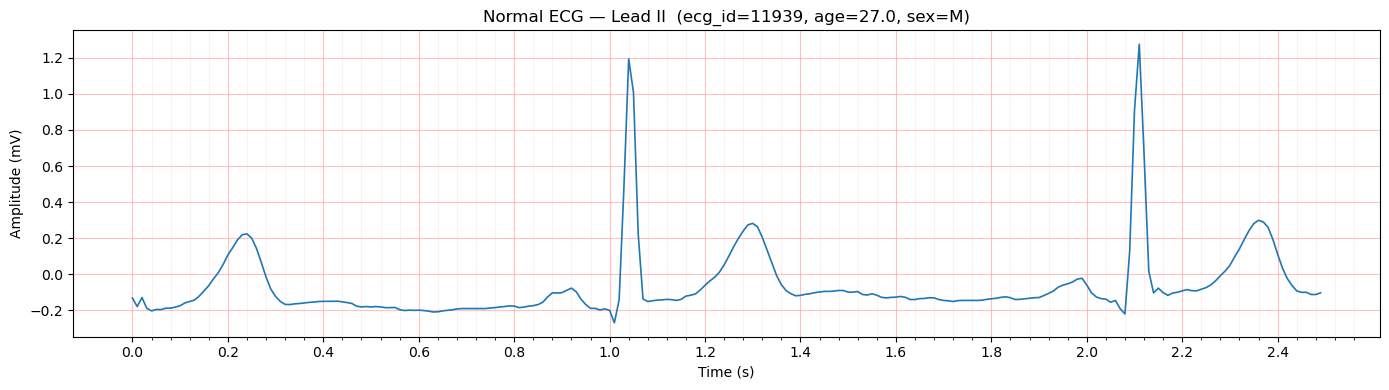

In [3]:
# ============================================================
# Plot 1: Normal heart waves annotating each signal segment
# ============================================================

# Pick a normal ECG and annotate the waves on Lead II (best for rhythm)
row = pick_example("NORM", n=1).iloc[0]
signal = load_signal(row)

fs = SAMPLING_RATE
t = np.arange(signal.shape[1]) / fs

fig, ax = plt.subplots(figsize=(14, 4))
# show first 2.5 seconds for clarity
end = int(2.5 * fs)
lead_ii = signal[1, :end]
ax.plot(t[:end], lead_ii, color="#1f77b4", lw=1.2)

# ECG-paper-style grid (small grid = 40ms, large grid = 200ms)
ax.set_xticks(np.arange(0, 2.6, 0.2), minor=False)
ax.set_xticks(np.arange(0, 2.6, 0.04), minor=True)
ax.grid(which="major", color="#ff9999", alpha=0.6)
ax.grid(which="minor", color="#ffcccc", alpha=0.3)

ax.set_title(f"Normal ECG — Lead II  (ecg_id={row.ecg_id}, age={row.age}, sex={'M' if row.sex==0 else 'F'})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()

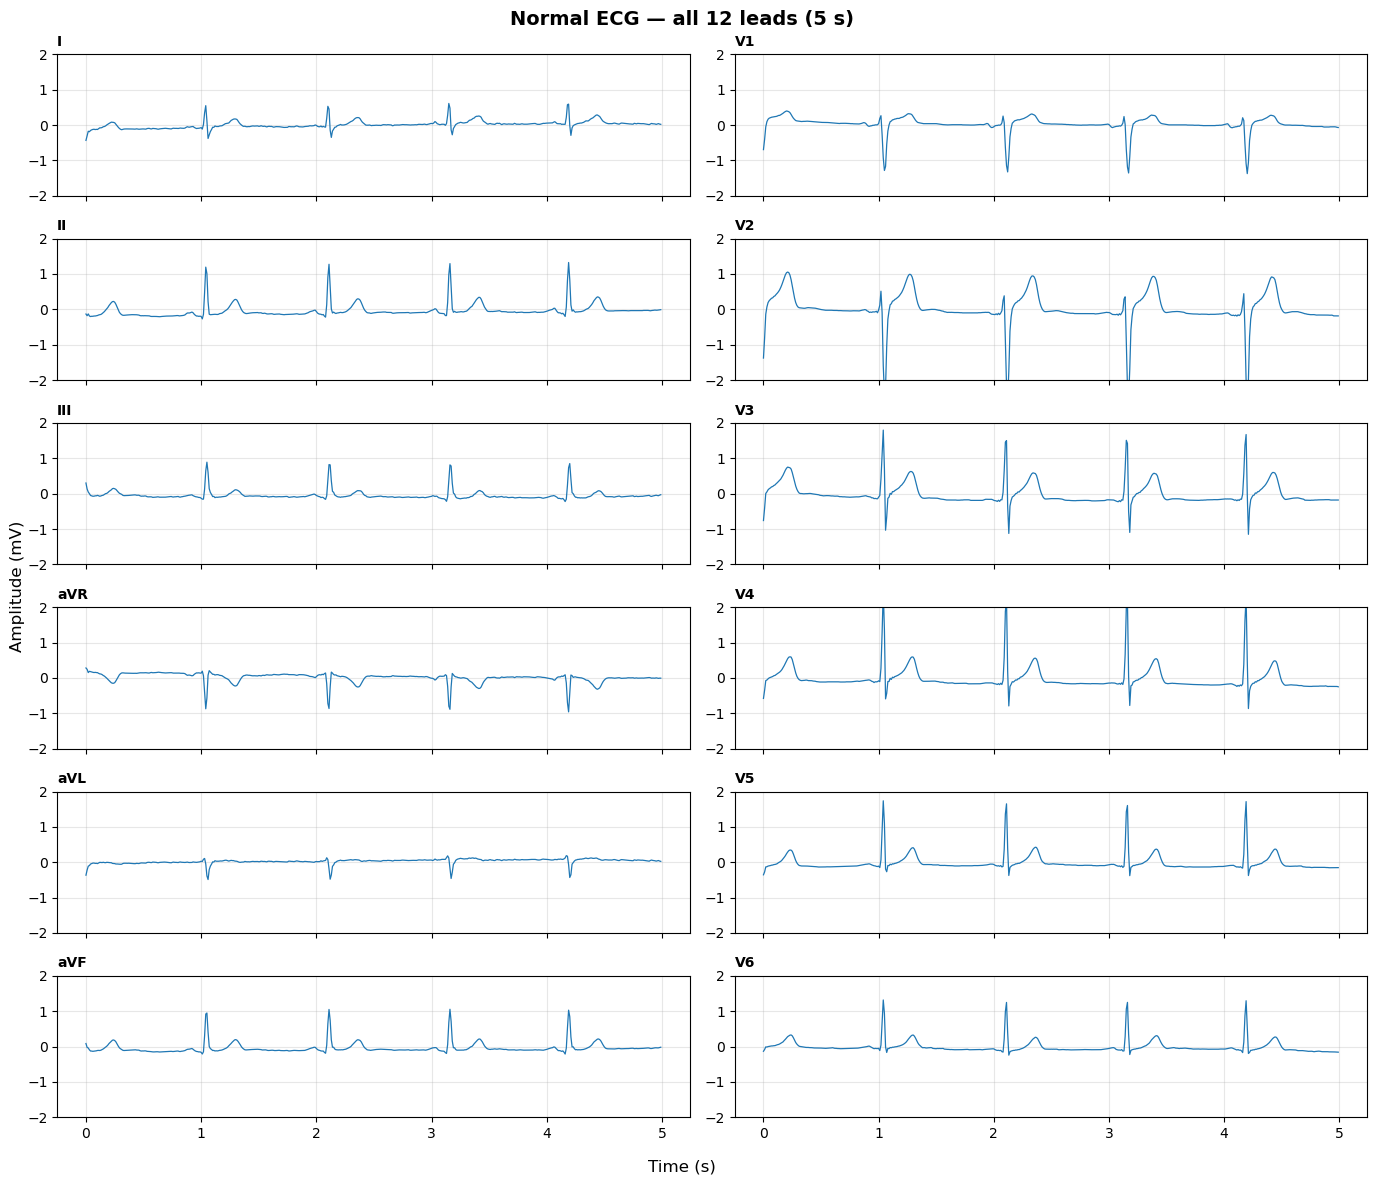

In [4]:
# ============================================================
# Plot 2: 12 lead comparison for the same ECG example from plot 1
# ============================================================

fig, axes = plt.subplots(6, 2, figsize=(14, 12), sharex=True)
end = int(5 * fs)   # 5 seconds
t5 = np.arange(end) / fs

# Standard 12-lead layout: 6 rows × 2 cols
# left col: I, II, III, aVR, aVL, aVF   right col: V1..V6
order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
positions = [(i, 0) for i in range(6)] + [(i, 1) for i in range(6)]

for lead_idx, pos in zip(order, positions):
    ax = axes[pos]
    ax.plot(t5, signal[lead_idx, :end], color="#1f77b4", lw=0.9)
    ax.set_title(LEAD_NAMES[lead_idx], loc="left", fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.set_ylim(-2, 2)

fig.suptitle("Normal ECG — all 12 leads (5 s)", fontsize=14, fontweight="bold")
fig.supxlabel("Time (s)")
fig.supylabel("Amplitude (mV)")
plt.tight_layout()
plt.show()

Observation:
- Lead II usually has the clearest rhythem lead (very visible P-QRS-T wave)
- aVR is always inverted since it sees heart from right shoulder, electric axis is also inverted
- V1-V6 from right to left, R wave becomes bigger while S wave becomes smaller (R wave progression)

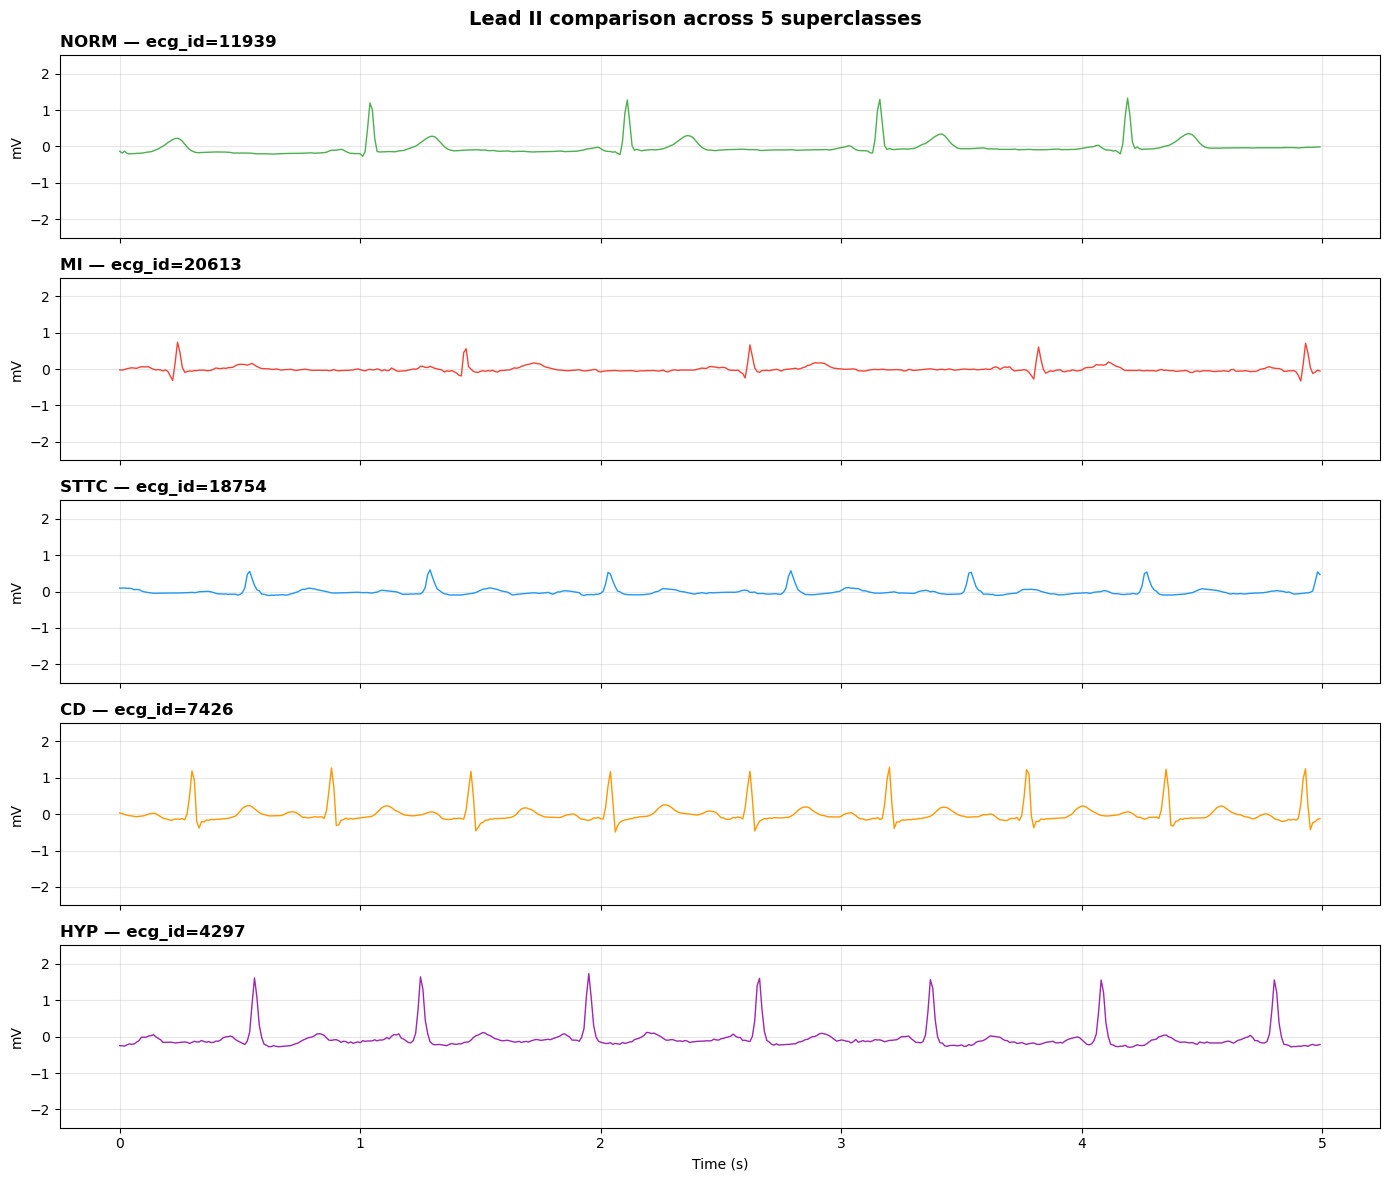

In [5]:
# ============================================================
# Plot 3: normal vs abnormal ECG (Lead II)
# ============================================================
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
end = int(5 * fs)
t5 = np.arange(end) / fs

class_colors = {"NORM":"#4CAF50","MI":"#F44336","STTC":"#2196F3","CD":"#FF9800","HYP":"#9C27B0"}

for ax, sc in zip(axes, SUPERCLASSES):
    row = pick_example(sc, n=1).iloc[0]
    sig = load_signal(row)
    ax.plot(t5, sig[1, :end], color=class_colors[sc], lw=1.0)
    ax.set_title(f"{sc} — ecg_id={row.ecg_id}", loc="left", fontweight="bold")
    ax.set_ylabel("mV")
    ax.grid(alpha=0.3)
    ax.set_ylim(-2.5, 2.5)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Lead II comparison across 5 superclasses", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

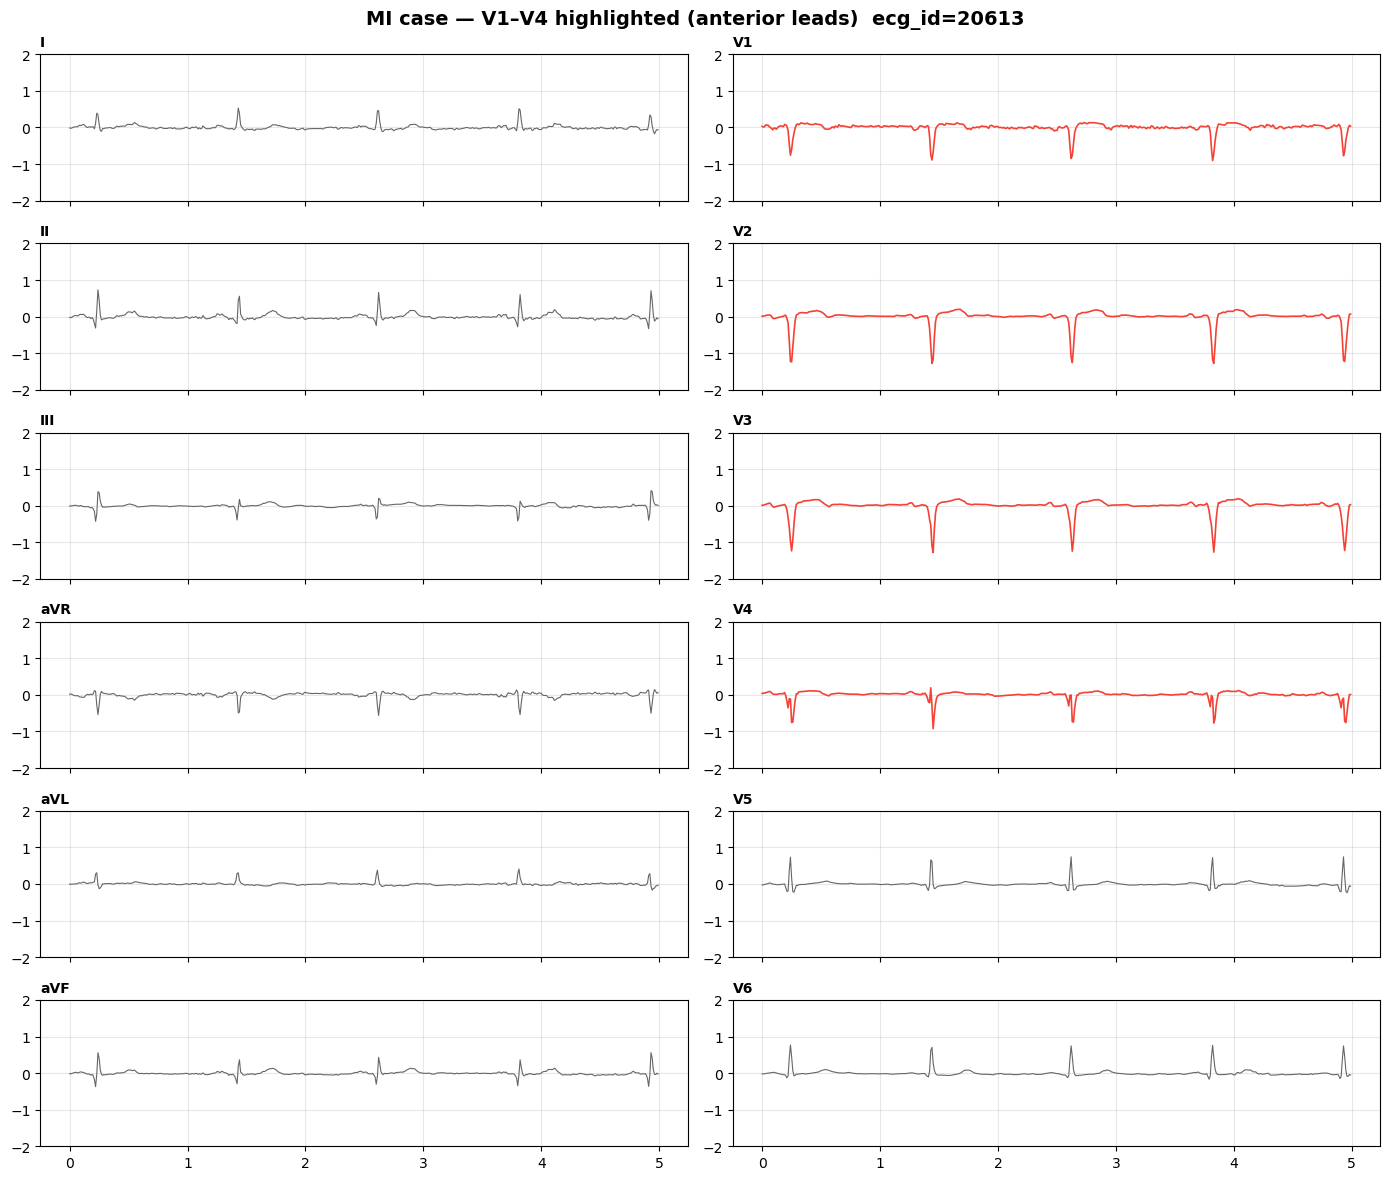

In [6]:
# ============================================================
# Plot 4: MI is most evident in which lead?
# Anterior wall MI is most evident in the precordial leads V1 to V4 
# ============================================================
# Pick a clear MI case and show all 12 leads to see where the abnormality lives
row = pick_example("MI", n=1).iloc[0]
sig = load_signal(row)

fig, axes = plt.subplots(6, 2, figsize=(14, 12), sharex=True)
end = int(5 * fs)
t5 = np.arange(end) / fs
positions = [(i, 0) for i in range(6)] + [(i, 1) for i in range(6)]

# highlight precordial leads (V1-V4) where anterior MI shows up
highlight = {6, 7, 8, 9}   # V1, V2, V3, V4

for lead_idx, pos in zip(range(12), positions):
    ax = axes[pos]
    color = "#F44336" if lead_idx in highlight else "#666666"
    lw = 1.2 if lead_idx in highlight else 0.8
    ax.plot(t5, sig[lead_idx, :end], color=color, lw=lw)
    ax.set_title(LEAD_NAMES[lead_idx], loc="left", fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.set_ylim(-2, 2)

fig.suptitle(f"MI case — V1–V4 highlighted (anterior leads)  ecg_id={row.ecg_id}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

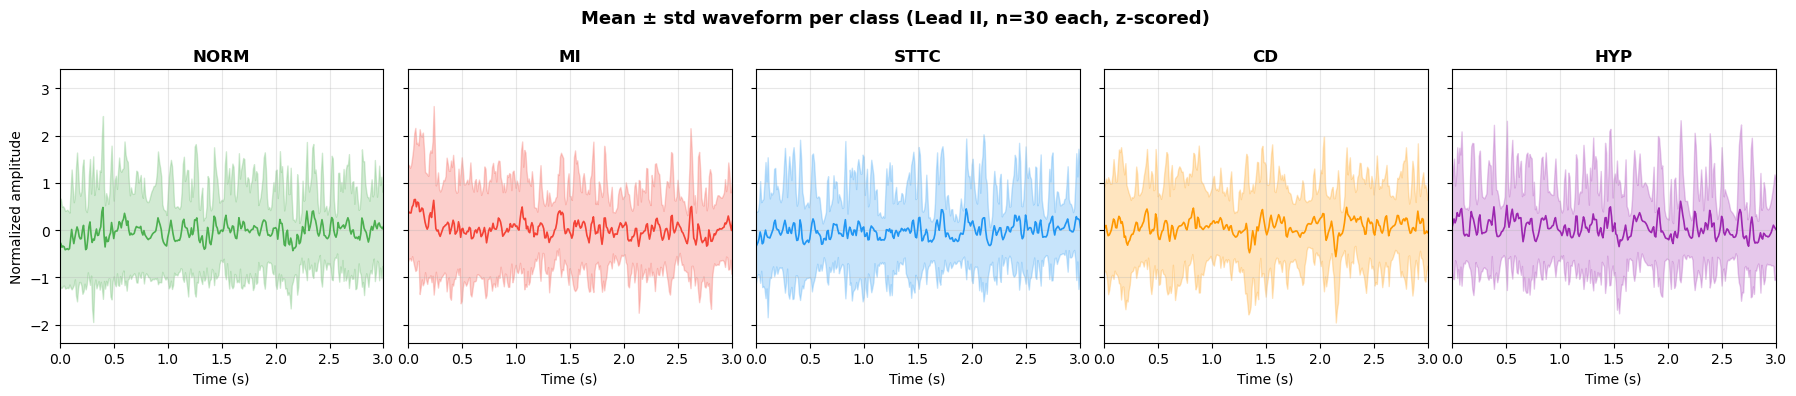

In [7]:
# ============================================================
# Plot 5: average heartbeat waveform in each superclass
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
n_samples = 30   # average over 30 cases per class

for ax, sc in zip(axes, SUPERCLASSES):
    examples = pick_example(sc, n=n_samples, single_label=True)
    sigs = []
    for _, r in examples.iterrows():
        s = load_signal(r)[1]    # lead II
        s = (s - s.mean()) / (s.std() + 1e-8)   # z-score per signal
        sigs.append(s)
    sigs = np.array(sigs)
    mean = sigs.mean(axis=0)
    std = sigs.std(axis=0)
    t_full = np.arange(len(mean)) / fs

    ax.plot(t_full, mean, color=class_colors[sc], lw=1.2)
    ax.fill_between(t_full, mean-std, mean+std, alpha=0.25, color=class_colors[sc])
    ax.set_title(sc, fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 3)

axes[0].set_ylabel("Normalized amplitude")
fig.suptitle("Mean ± std waveform per class (Lead II, n=30 each, z-scored)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
sig.shape

(12, 1000)